In [2]:
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured as s2u
from scipy.signal import medfilt, spectrogram, detrend
from librosa import power_to_db
from librosa.feature import melspectrogram, mfcc
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from keras.models import load_model # type: ignore


In [4]:
model = load_model(r"D:\Projects\Буксов_аксл\models\Akselerometers_gen_Velaro_bs_18000\20260302_1150\Akselerometers_gen_Velaro_bs_18000.keras"
                   )


In [ ]:
raw_data_aks = np.load('data\\data_norm_128.npy')
raw_data_way = np.load('data\\raw_data_way.npy')

print('raw_data_aks', raw_data_aks.shape, 'raw_data_way', raw_data_way.shape)

FFT = 512
SR = 3000
chunk_size = 6000 * SR
n_mels = 128
noverlap = 32
hop_length = FFT - noverlap

In [ ]:
# срез [5157333: 10314666]

data_aks_chunk = raw_data_aks
data_way_chunk = raw_data_way
# data_way_chunk = raw_data_way
print(data_aks_chunk.shape)
print(np.round(data_aks_chunk.shape[0] / SR), 'секунд')


# data procc

data_aks_ = medfilt(data_aks_chunk, kernel_size=5)  # фильтруется шум

f, t, Sxx = spectrogram(
    data_aks_, fs=SR,
    nperseg=FFT, noverlap=32,
    detrend='linear', mode='psd')

mel_spec = melspectrogram(
    S=Sxx, sr=SR,
    n_fft=FFT, n_mels=128,
    power=2, center=False)

mfcc_spec = mfcc(
    S=power_to_db(mel_spec),
    sr=SR, n_mfcc=128,
    dct_type=2, norm="ortho",)

mfcc_spec_dtr = detrend(mfcc_spec, type='linear')

y_pred = model.predict(mfcc_spec_dtr.T)
y_pred_f = savgol_filter(y_pred.reshape((-1)), window_length=200, polyorder=4)
y_pred_f_i = np.interp(np.linspace(0, 1, data_way_chunk.shape[0]), np.linspace(0, 1, y_pred.shape[0]), y_pred_f.reshape((-1)))

plt.figure(figsize=(12, 4))

plt.plot(y_pred_f_i, color='r', label='y_pred_f')
plt.plot(data_way_chunk, color='b', label='y_true')

# срез на тредь [data_way_chunk.shape[0] // 3: data_way_chunk.shape[0] // 3 * 2]

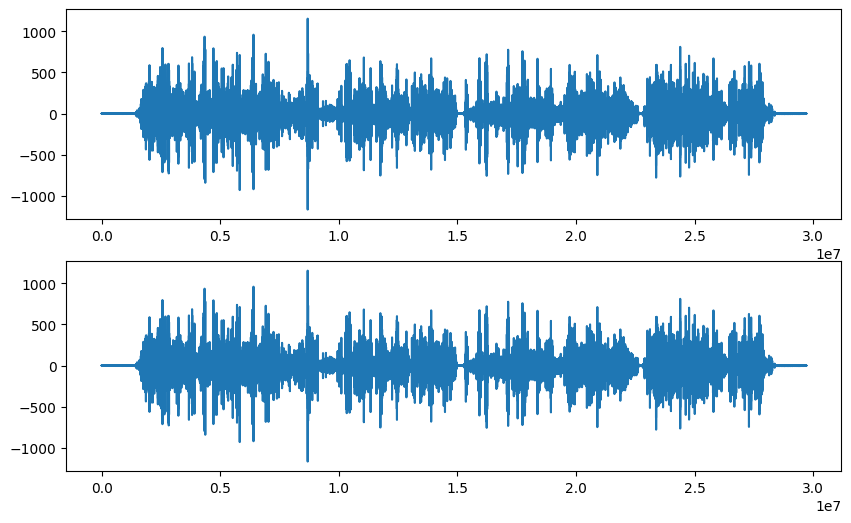

In [8]:
db1 = np.load(r'data\aks_1.npy')
db2 = np.load(r'data\aks_x_dbx2.npy')

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(db1)
ax[1].plot(db2)

In [7]:
val = 7900000
print(db1[val], db2[val])

-6.03415 -6.03415


### С Генератором

All data shape (28525415,) (28525415,)
Akselerometers_gen_Velaro_bs_18000
[<KerasTensor shape=(None, 128), dtype=float32, sparse=False, ragged=False, name=input_layer>]
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_54>]
(37, 128) (37, 1)
batch_size 18000


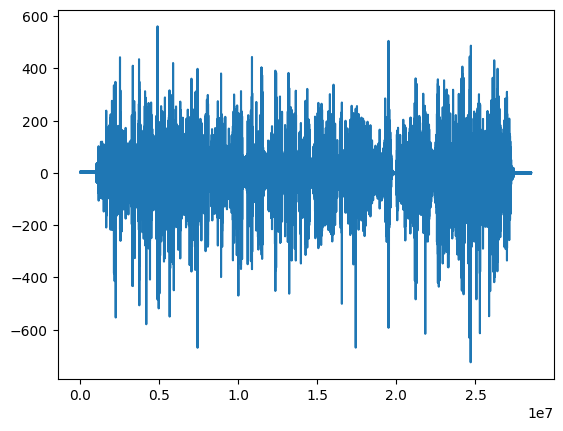

In [5]:
from datagen import DataGen

X_test = np.load(r'data\20180920_205115_DBX1.npy')
y_test = np.load(r'data\20180920_205115_mway.npy')

generator = DataGen(X_test, y_test, batch_size=int(model.name.split('_')[-1]), smpl_r=2000)
# print(generator.__len__())
# generator.plot_batch_spec(1000)
print(model.name)
print(model.inputs)
print(model.outputs)
X, y = generator.__getitem__(0)
batch = X.shape[0]
print(X.shape, y.shape)
print('batch_size', generator.batch_size)
del X, y


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━

C:\Users\a_belov\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\a_belov\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


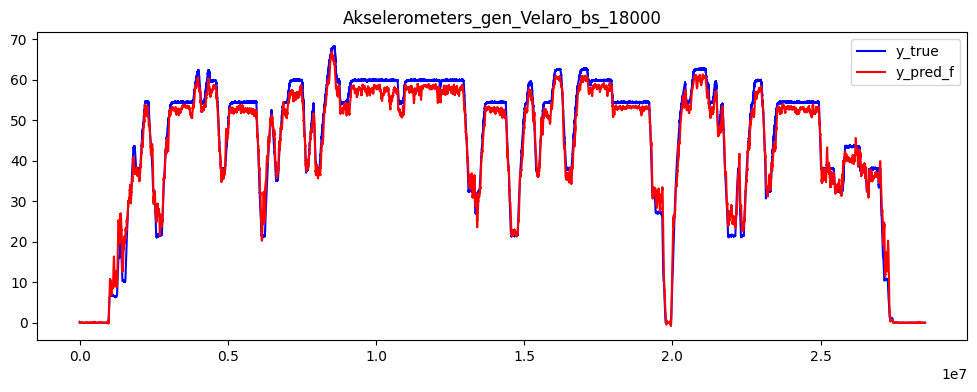

In [6]:
from timeit import default_timer as timer

d_len = generator.__len__()
y_pred = np.zeros((d_len * batch, 1))


for i in range(d_len):
    y_pred[i*batch: (i+1)*batch] = model.predict(generator.__getitem__(i)[0])

# [int(2e6): int(3e6)]
st = timer()
y_pred_f = savgol_filter(y_pred.reshape((-1)), window_length=200, polyorder=4)
y_pred_f_i = np.interp(np.linspace(0, 1, y_test.shape[0]), np.linspace(0, 1, y_pred.shape[0]), y_pred_f.reshape((-1)))
en = timer()

plt.figure(figsize=(12, 4))
plt.plot(y_test, color='b', label='y_true')
plt.plot(y_pred_f_i, color='r', label='y_pred_f')
plt.title(f'{model.name}')
plt.legend()


In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(y_test, color='b', label='y_true')
plt.plot(y_pred_f_i, color='r', label='y_pred_f')
plt.title(f'{model.name}')
plt.ylabel('м/с')
plt.xlabel('отсчеты')
plt.legend()